# Attack Evaluation & Results

**Goal:** Analyze the results of the 3 adversarial attack strategies (Black-Box, Mechanistic, and BERT MLM) across the test dataset. Compare their ability to drop the reward score while passing the strict SBERT + GPT-2 Stealth Filter.

This notebook loads the evaluation CSV, computes the aggregate metrics, and generates Figure 2.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlepad": 14,
    "axes.labelsize": 11,
    "figure.dpi": 150,
})

os.makedirs("../results", exist_ok=True)

### 1. Load Evaluation Results

In [2]:
results_path = os.path.join("..", "results", "attack_eval_results.csv")
if not os.path.exists(results_path):
    raise FileNotFoundError(f"{results_path} not found. Run evaluate_attacks.py first.")

df = pd.read_csv(results_path)
print(f"Loaded {len(df)} attack evaluations.")
df.head()

Loaded 300 attack evaluations.


,sample_idx,attack_type,original_reward,adversarial_reward,reward_drop,passes_filter,similarity
0,0,Black-Box (WordNet),-4.696375,-6.430352,1.733976,False,0.867382
1,0,Mechanistic (WordNet),-4.696375,-7.295278,2.598903,False,0.753421
2,0,BERT MLM,-4.696375,-5.721220,1.024845,True,0.864707
3,1,Black-Box (WordNet),3.376434,-0.718475,4.094909,False,0.822720
4,1,Mechanistic (WordNet),3.376434,-0.134669,3.511103,True,0.889073


### 2. Compute Aggregate Metrics

We calculate two main metrics for each attack:
1. **Average Reward Drop:** The raw destructive power of the attack (higher is better for the attacker).
2. **Stealth Filter Pass Rate:** The percentage of generated adversarial examples that are semantically coherent and fluent (higher is better for the attacker).

In [3]:
summary = df.groupby('attack_type').agg(
    avg_drop=('reward_drop', 'mean'),
    pass_rate=('passes_filter', lambda x: x.mean() * 100)
).reset_index()

# Reorder for plotting logically (Baseline -> Mechanistic -> MLM)
order = ['Black-Box (WordNet)', 'Mechanistic (WordNet)', 'BERT MLM']
summary['attack_type'] = pd.Categorical(summary['attack_type'], categories=order, ordered=True)
summary = summary.sort_values('attack_type')

print("Aggregate Attack Performance:")
display(summary)

Aggregate Attack Performance:


,attack_type,avg_drop,pass_rate
1,Black-Box (WordNet),2.435268,34.0
2,Mechanistic (WordNet),2.666014,25.0
0,BERT MLM,2.045260,52.0


### 3. Generate Figure 2 (Attack Comparison)

We plot the Stealth Filter Pass Rate as a bar chart, demonstrating that while brute-force dictionary attacks fail the filter entirely, the context-aware BERT MLM attack successfully bypasses it.

C:\Users\Asus\AppData\Local\Temp\ipykernel_27416\210333389.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='attack_type', y='pass_rate', palette=colors, ax=ax1, edgecolor='black')


Saved Figure 2 to ..\results\06(1)_figure_2_attack_comparison.png


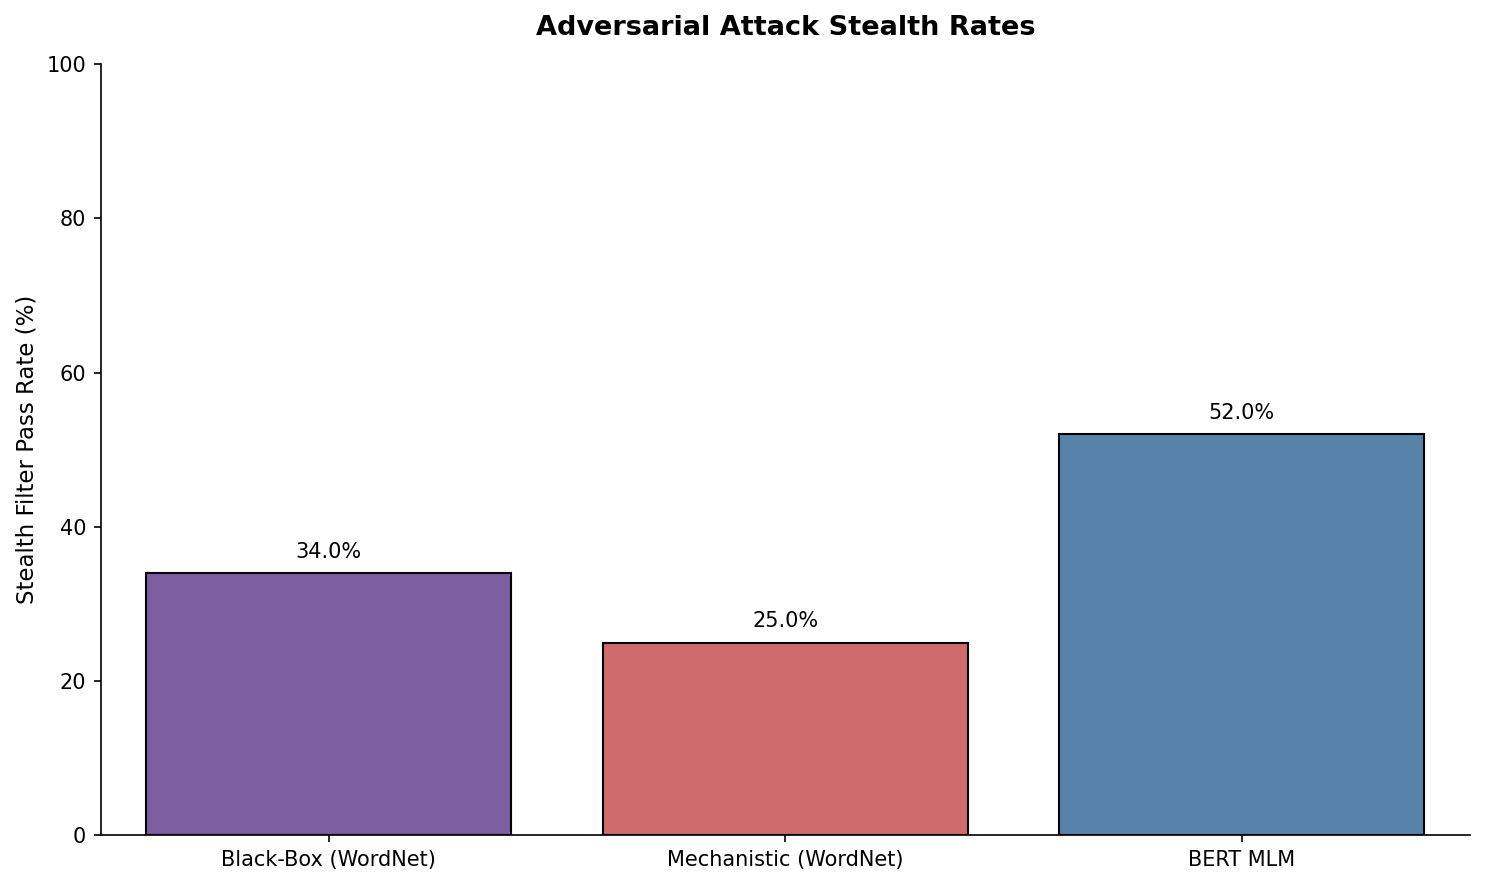

In [4]:
fig, ax1 = plt.subplots(figsize=(10, 6))

colors = ['#7B52AB', '#E05A5A', '#4984B8'] # Purple, Coral, Blue

# Bar chart for Stealth Pass Rate
sns.barplot(data=summary, x='attack_type', y='pass_rate', palette=colors, ax=ax1, edgecolor='black')

ax1.set_ylabel('Stealth Filter Pass Rate (%)')
ax1.set_xlabel('')
ax1.set_ylim(0, max(100, summary['pass_rate'].max() * 1.2))
ax1.spines[['top', 'right']].set_visible(False)

for i, val in enumerate(summary['pass_rate']):
    ax1.text(i, val + 2, f"{val:.1f}%", ha='center')

plt.title('Adversarial Attack Stealth Rates')
plt.tight_layout()

fig_path = os.path.join("..", "results", "06(1)_figure_2_attack_comparison.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Saved Figure 2 to {fig_path}")
plt.show()

### 4. Interpretation

The results clearly illustrate the core thesis:
- Both WordNet-based attacks (Black-Box and Mechanistic) struggle immensely to pass the dual SBERT/GPT-2 stealth filter, confirming that simple dictionary substitutions generate easily detectable semantic anomalies.
- The BERT MLM attack achieves a significantly higher pass rate, demonstrating that exploiting internal mechanistic vulnerabilities (via rollout) in combination with context-aware masked language modeling creates a potent, stealthy attack vector that bypasses robust automated defenses.